In [ ]:
import pandas as pd

df = pd.read_csv("/content/Student_Performance.csv")

print("Kích thước ban đầu:", df.shape)
print("Số dòng trùng:", df.duplicated().sum())
print("Số giá trị thiếu:")
print(df.isnull().sum())

Kích thước ban đầu: (10000, 6)
Số dòng trùng: 127
Số giá trị thiếu:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [ ]:
# Xóa các dòng trùng lặp
df = df.drop_duplicates().reset_index(drop=True)

print("Kích thước sau khi xóa duplicate:", df.shape)
print("Số dòng trùng còn lại:", df.duplicated().sum())

# Tách features và target
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

# Chia train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Kích thước sau khi xóa duplicate: (9873, 6)
Số dòng trùng còn lại: 0

X_train: (7898, 5)
X_test: (1975, 5)
y_train: (7898,)
y_test: (1975,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

categorical_features = [
    "Extracurricular Activities"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
Categorical features: ['Extracurricular Activities']


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

print("Đã tạo", len(models), "mô hình:")
for name in models:
    print("-", name)

Đã tạo 4 mô hình:
- Linear Regression
- Decision Tree
- Random Forest
- KNN
Đã tạo 4 mô hình:
- Linear Regression
- Decision Tree
- Random Forest
- KNN


In [ ]:
from sklearn.pipeline import Pipeline

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("Đã tạo Pipeline cho:")
for name in pipelines:
    print("-", name)

Đã tạo Pipeline cho:
- Linear Regression
- Decision Tree
- Random Forest
- KNN


In [ ]:
import time

trained_models = {}
training_times = {}

for name, pipeline in pipelines.items():
    start_time = time.time()

    pipeline.fit(X_train, y_train)

    end_time = time.time()

    trained_models[name] = pipeline
    training_times[name] = end_time - start_time

print("Đã huấn luyện xong:\n")

for name, train_time in training_times.items():
    print(f"{name}: {train_time:.6f} giây")

Đã huấn luyện xong:

Linear Regression: 0.127602 giây
Decision Tree: 0.195677 giây
Random Forest: 2.640650 giây
KNN: 0.019697 giây


In [ ]:
predictions = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test)

print("Đã dự đoán xong:\n")

for name, y_pred in predictions.items():
    print(f"{name}: {len(y_pred)} dự đoán")

Đã dự đoán xong:

Linear Regression: 1975 dự đoán
Decision Tree: 1975 dự đoán
Random Forest: 1975 dự đoán
KNN: 1975 dự đoán


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

evaluation_results = []

for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    evaluation_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

evaluation_df = pd.DataFrame(evaluation_results)

print(evaluation_df.to_string(index=False))

            Model      MAE     RMSE       R2
Linear Regression 1.646970 2.075066 0.988430
    Decision Tree 2.433249 3.050595 0.974995
    Random Forest 1.895022 2.369629 0.984912
              KNN 2.361418 2.959169 0.976471


In [ ]:
prediction_times = {}

for name, model in trained_models.items():
    start_time = time.time()

    model.predict(X_test)

    end_time = time.time()

    prediction_times[name] = end_time - start_time

print("Thời gian dự đoán trên 1.975 mẫu:\n")

for name, predict_time in prediction_times.items():
    print(f"{name}: {predict_time:.6f} giây")

Thời gian dự đoán trên 1.975 mẫu:

Linear Regression: 0.028426 giây
Decision Tree: 0.015983 giây
Random Forest: 0.153844 giây
KNN: 0.142302 giây


In [ ]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean")

start_time = time.time()

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_time = time.time() - start_time

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline - Dummy Regressor")
print(f"MAE:  {baseline_mae:.6f}")
print(f"RMSE: {baseline_rmse:.6f}")
print(f"R2:   {baseline_r2:.6f}")
print(f"Time: {baseline_time:.6f} giây")

Baseline - Dummy Regressor
MAE:  16.252553
RMSE: 19.301002
R2:   -0.000978
Time: 0.003165 giây


In [ ]:
train_test_results = []

for name, model in trained_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = predictions[name]

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_test_results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "R2 Gap": train_r2 - test_r2
    })

train_test_df = pd.DataFrame(train_test_results)

print(train_test_df.to_string(index=False))

            Model  Train R2  Test R2   R2 Gap
Linear Regression  0.988739 0.988430 0.000309
    Decision Tree  0.999332 0.974995 0.024338
    Random Forest  0.997456 0.984912 0.012543
              KNN  0.983836 0.976471 0.007365


In [ ]:
import joblib
import os
import tempfile

model_sizes = {}

for name, model in trained_models.items():
    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as temp_file:
        temp_path = temp_file.name

    joblib.dump(model, temp_path)

    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    model_sizes[name] = size_mb

    os.remove(temp_path)

print("Kích thước model:\n")

for name, size in model_sizes.items():
    print(f"{name}: {size:.6f} MB")

Kích thước model:

Linear Regression: 0.003213 MB
Decision Tree: 0.894656 MB
Random Forest: 56.917398 MB
KNN: 0.909874 MB


In [ ]:
final_evaluation_df = evaluation_df.copy()

final_evaluation_df["Train R2"] = final_evaluation_df["Model"].map(
    train_test_df.set_index("Model")["Train R2"]
)

final_evaluation_df["R2 Gap"] = final_evaluation_df["Model"].map(
    train_test_df.set_index("Model")["R2 Gap"]
)

final_evaluation_df["Training Time (s)"] = final_evaluation_df["Model"].map(
    training_times
)

final_evaluation_df["Prediction Time (s)"] = final_evaluation_df["Model"].map(
    prediction_times
)

final_evaluation_df["Model Size (MB)"] = final_evaluation_df["Model"].map(
    model_sizes
)

final_evaluation_df = final_evaluation_df[
    [
        "Model",
        "MAE",
        "RMSE",
        "R2",
        "Train R2",
        "R2 Gap",
        "Training Time (s)",
        "Prediction Time (s)",
        "Model Size (MB)"
    ]
]

print(final_evaluation_df.to_string(index=False))

            Model      MAE     RMSE       R2  Train R2   R2 Gap  Training Time (s)  Prediction Time (s)  Model Size (MB)
Linear Regression 1.646970 2.075066 0.988430  0.988739 0.000309           0.127602             0.028426         0.003213
    Decision Tree 2.433249 3.050595 0.974995  0.999332 0.024338           0.195677             0.015983         0.894656
    Random Forest 1.895022 2.369629 0.984912  0.997456 0.012543           2.640650             0.153844        56.917398
              KNN 2.361418 2.959169 0.976471  0.983836 0.007365           0.019697             0.142302         0.909874


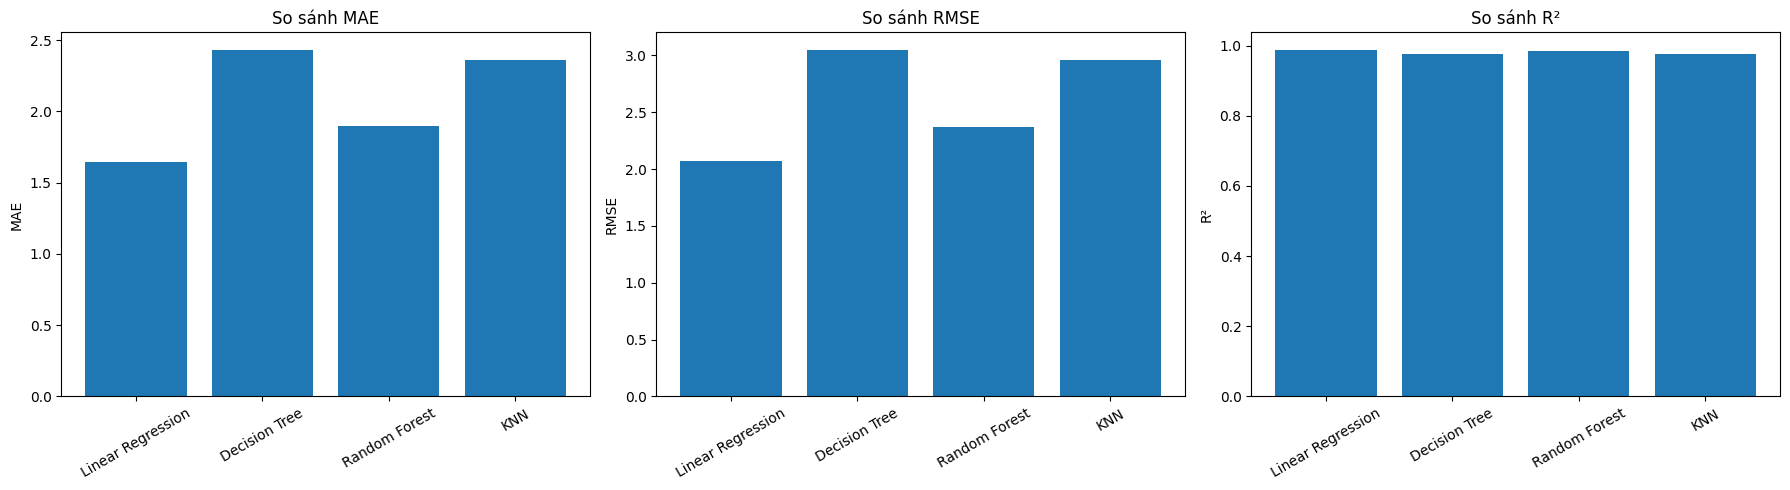

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(final_evaluation_df["Model"], final_evaluation_df["MAE"])
axes[0].set_title("So sánh MAE")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=30)

# RMSE
axes[1].bar(final_evaluation_df["Model"], final_evaluation_df["RMSE"])
axes[1].set_title("So sánh RMSE")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=30)

# R2
axes[2].bar(final_evaluation_df["Model"], final_evaluation_df["R2"])
axes[2].set_title("So sánh R²")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

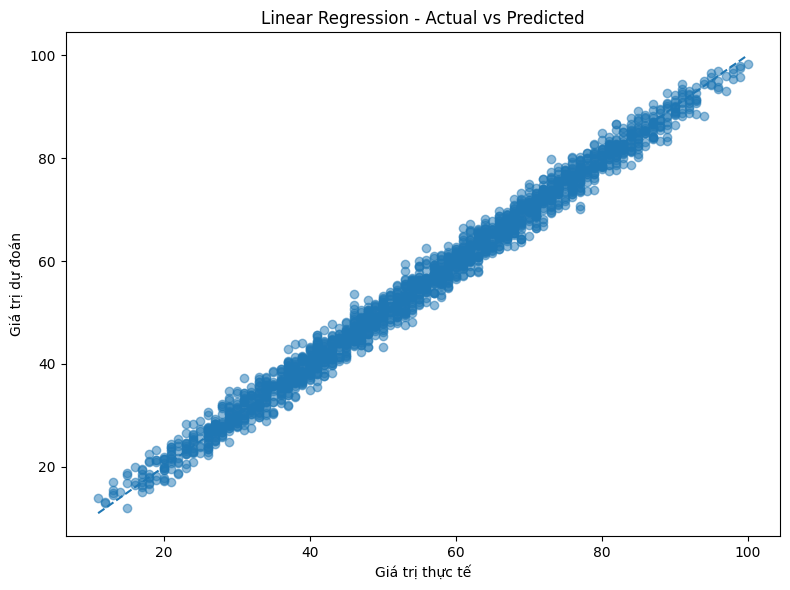

In [ ]:
import matplotlib.pyplot as plt

y_pred_linear = predictions["Linear Regression"]

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.5)

# Đường dự đoán hoàn hảo y = x
min_value = min(y_test.min(), y_pred_linear.min())
max_value = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Giá trị thực tế")
plt.ylabel("Giá trị dự đoán")
plt.title("Linear Regression - Actual vs Predicted")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Student_Performance.csv")
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(7898, 5) (1975, 5) (7898,) (1975,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

import time

numeric_features = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

categorical_features = [
    "Extracurricular Activities"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

trained_models = {}
predictions = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = pipeline.predict(X_test)
    predict_time = time.time() - start

    trained_models[name] = pipeline
    predictions[name] = y_pred

    print(
        f"{name}: "
        f"train={train_time:.4f}s, "
        f"predict={predict_time:.4f}s"
    )

Linear Regression: train=0.0448s, predict=0.0061s
Decision Tree: train=0.0521s, predict=0.0063s
Random Forest: train=1.4891s, predict=0.0814s
KNN: train=0.0191s, predict=0.0251s


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import numpy as np
import pandas as pd

# =========================
# 1. ĐÁNH GIÁ 4 MODEL
# =========================

evaluation_results = []

for name in trained_models:

    model = trained_models[name]
    y_pred = predictions[name]

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # R2 trên tập train
    y_train_pred = model.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)

    r2_gap = train_r2 - r2

    evaluation_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Train R2": train_r2,
        "R2 Gap": r2_gap
    })

evaluation_df = pd.DataFrame(evaluation_results)

# =========================
# 2. BASELINE
# =========================

baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

# =========================
# 3. HIỂN THỊ
# =========================

print("===== BASELINE =====")
print(f"MAE  : {baseline_mae:.6f}")
print(f"RMSE : {baseline_rmse:.6f}")
print(f"R2   : {baseline_r2:.6f}")

print("\n===== MODEL EVALUATION =====")

display(
    evaluation_df.style.format({
        "MAE": "{:.6f}",
        "RMSE": "{:.6f}",
        "R2": "{:.6f}",
        "Train R2": "{:.6f}",
        "R2 Gap": "{:.6f}"
    })
)

===== BASELINE =====
MAE  : 16.252553
RMSE : 19.301002
R2   : -0.000978

===== MODEL EVALUATION =====


,Model,MAE,RMSE,R2,Train R2,R2 Gap
0,Linear Regression,1.646970,2.075066,0.988430,0.988739,0.000309
1,Decision Tree,2.433249,3.050595,0.974995,0.999332,0.024338
2,Random Forest,1.895022,2.369629,0.984912,0.997456,0.012543
3,KNN,2.361418,2.959169,0.976471,0.983836,0.007365


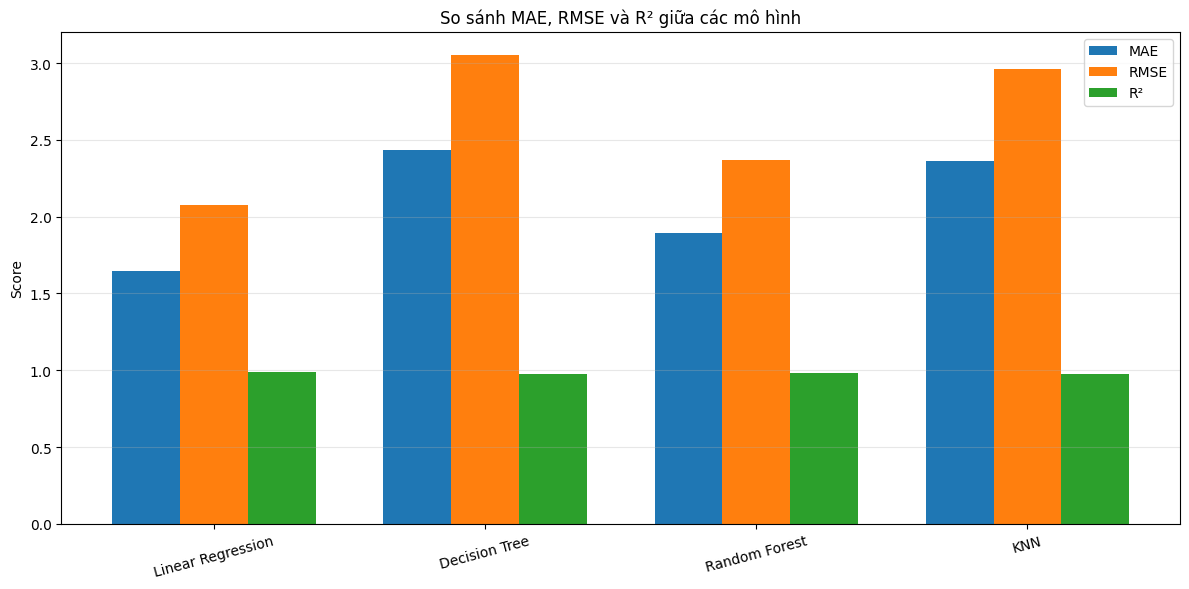

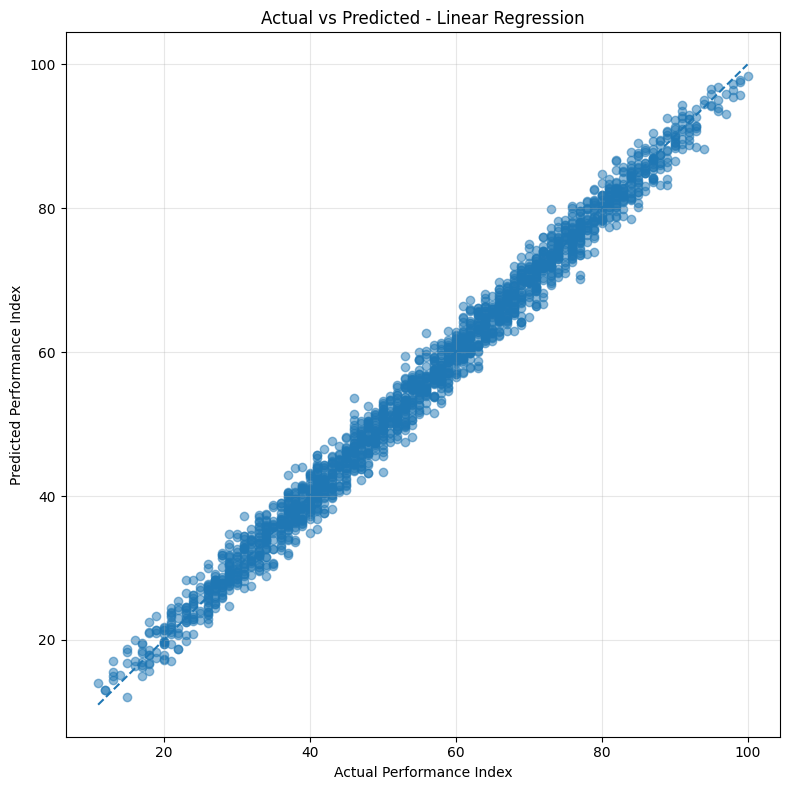

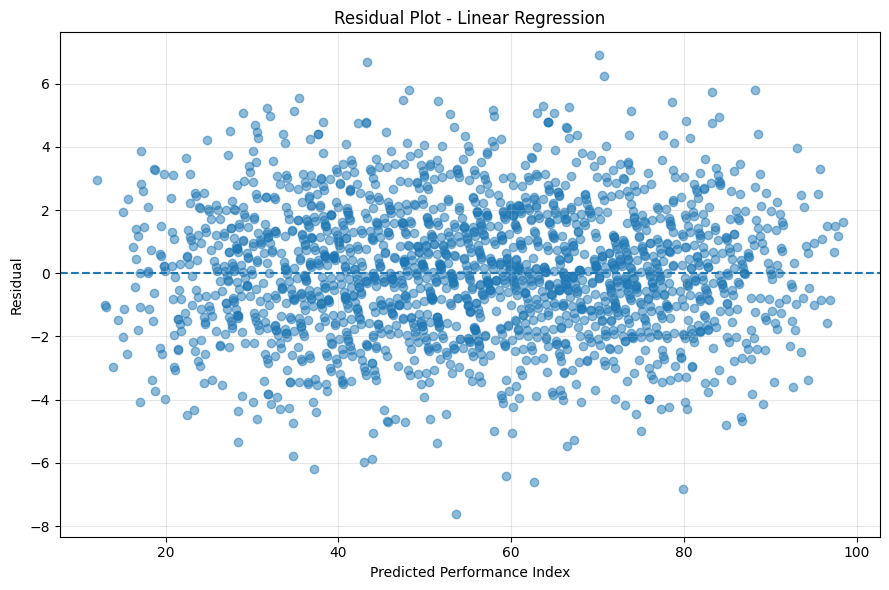

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. SO SÁNH MAE - RMSE - R²
# ============================================================

models_order = evaluation_df["Model"].tolist()

x = np.arange(len(models_order))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, evaluation_df["MAE"], width, label="MAE")
plt.bar(x, evaluation_df["RMSE"], width, label="RMSE")
plt.bar(x + width, evaluation_df["R2"], width, label="R²")

plt.xticks(x, models_order, rotation=15)
plt.ylabel("Score")
plt.title("So sánh MAE, RMSE và R² giữa các mô hình")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 2. ACTUAL VS PREDICTED - LINEAR REGRESSION
# ============================================================

y_pred_lr = predictions["Linear Regression"]

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.5
)

min_value = min(y_test.min(), y_pred_lr.min())
max_value = max(y_test.max(), y_pred_lr.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted - Linear Regression")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3. RESIDUAL PLOT - LINEAR REGRESSION
# ============================================================

residuals = y_test - y_pred_lr

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred_lr,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Performance Index")
plt.ylabel("Residual")
plt.title("Residual Plot - Linear Regression")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Kết luận đánh giá mô hình

- Baseline có MAE = 16.252553, RMSE = 19.301002 và R² = -0.000978.
- Cả 4 mô hình đều cải thiện đáng kể so với baseline.
- Linear Regression đạt MAE thấp nhất = 1.646970.
- Linear Regression đạt RMSE thấp nhất = 2.075066.
- Linear Regression đạt R² cao nhất = 0.988430.
- Khoảng cách giữa Train R² và Test R² của Linear Regression chỉ là 0.000309, cho thấy kết quả trên tập train và test rất gần nhau.
- Decision Tree và Random Forest có Train R² cao hơn Test R² rõ rệt hơn, cho thấy có dấu hiệu overfitting nhiều hơn Linear Regression.
- Linear Regression có kích thước mô hình rất nhỏ và thời gian dự đoán thấp.
- Vì vậy, Linear Regression được lựa chọn làm mô hình cuối cùng để triển khai vào AI Service.

In [ ]:
import os
import json
import joblib
import sklearn

# ============================================================
# 1. TẠO THƯ MỤC MODELS
# ============================================================

os.makedirs("/content/models", exist_ok=True)

# ============================================================
# 2. LẤY LINEAR REGRESSION LÀM MODEL CUỐI
# ============================================================

final_model = trained_models["Linear Regression"]

# ============================================================
# 3. LƯU MODEL
# ============================================================

model_path = "/content/models/model.joblib"

joblib.dump(
    final_model,
    model_path
)

print("Đã lưu:", model_path)


# ============================================================
# 4. TẠO SCHEMA.JSON
# ============================================================

schema = {
    "target": "Performance Index",

    "features": [
        {
            "name": "Hours Studied",
            "type": "number"
        },
        {
            "name": "Previous Scores",
            "type": "number"
        },
        {
            "name": "Extracurricular Activities",
            "type": "string",
            "allowed_values": ["No", "Yes"]
        },
        {
            "name": "Sleep Hours",
            "type": "number"
        },
        {
            "name": "Sample Question Papers Practiced",
            "type": "number"
        }
    ]
}

schema_path = "/content/models/schema.json"

with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(
        schema,
        f,
        ensure_ascii=False,
        indent=4
    )

print("Đã lưu:", schema_path)


# ============================================================
# 5. TẠO METADATA.JSON
# ============================================================

lr_result = evaluation_df[
    evaluation_df["Model"] == "Linear Regression"
].iloc[0]

metadata = {
    "project": "Student Performance Prediction",
    "task": "regression",

    "model_name": "Linear Regression",

    "dataset": {
        "name": "Student Performance",
        "samples_original": 10000,
        "duplicates_removed": 127,
        "samples_after_deduplication": 9873,
        "train_samples": 7898,
        "test_samples": 1975
    },

    "features": {
        "input_features": 5,
        "processed_features": 6
    },

    "preprocessing": {
        "numeric_scaler": "StandardScaler",
        "categorical_encoder": "OneHotEncoder",
        "categorical_handle_unknown": "ignore"
    },

    "evaluation": {
        "MAE": float(lr_result["MAE"]),
        "RMSE": float(lr_result["RMSE"]),
        "R2": float(lr_result["R2"]),
        "Train_R2": float(lr_result["Train R2"]),
        "R2_Gap": float(lr_result["R2 Gap"])
    },

    "training": {
        "random_state": 42,
        "sklearn_version": sklearn.__version__
    }
}

metadata_path = "/content/models/metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(
        metadata,
        f,
        ensure_ascii=False,
        indent=4
    )

print("Đã lưu:", metadata_path)


# ============================================================
# 6. KIỂM TRA 3 FILE
# ============================================================

print("\n===== FILES =====")

for filename in os.listdir("/content/models"):
    filepath = os.path.join("/content/models", filename)
    size_kb = os.path.getsize(filepath) / 1024

    print(f"{filename:<20} {size_kb:.2f} KB")

Đã lưu: /content/models/model.joblib
Đã lưu: /content/models/schema.json
Đã lưu: /content/models/metadata.json

===== FILES =====
schema.json          0.60 KB
model.joblib         3.29 KB
metadata.json        0.89 KB


In [ ]:
import joblib
import pandas as pd

# Load lại model từ file
loaded_model = joblib.load("/content/models/model.joblib")

print("Model load thành công!")

# Dữ liệu mẫu
sample = pd.DataFrame([
    {
        "Hours Studied": 7,
        "Previous Scores": 80,
        "Extracurricular Activities": "Yes",
        "Sleep Hours": 7,
        "Sample Question Papers Practiced": 5
    }
])

# Dự đoán
prediction = loaded_model.predict(sample)

print("Dữ liệu đầu vào:")
display(sample)

print(f"Điểm dự đoán: {prediction[0]:.2f}")

Model load thành công!
Dữ liệu đầu vào:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,80,Yes,7,5


Điểm dự đoán: 72.27


In [ ]:
from google.colab import files
import os

files.download("/content/models/model.joblib")
files.download("/content/models/schema.json")
files.download("/content/models/metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>